Saving Q1_Hospital_ER_Dataset.csv to Q1_Hospital_ER_Dataset.csv
First 5 rows:
  PatientID  Age  Gender       ArrivalTime TriageLevel  WaitingTimeMinutes  \
0     P1001   52  Female   21/02/2026 3:00     Level 5               204.0   
1     P1002   15  Female   24/02/2026 8:15     Level 3                58.0   
2     P1003   72  Female   08/02/2026 4:55     Level 5                 NaN   
3     P1004   61  Female  04/02/2026 21:55     Level 3                66.0   
4     P1005   21   Other   18/02/2026 2:45     Level 1                29.0   

  DoctorAssigned AdmissionStatus  
0       Dr. Khan      Discharged  
1       Dr. Sara     Transferred  
2       Dr. Noor      Discharged  
3       Dr. Noor      Discharged  
4        Dr. Ali        admitted  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PatientID           88 

/tmp/ipykernel_1697/1401248630.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1697/1401248630.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

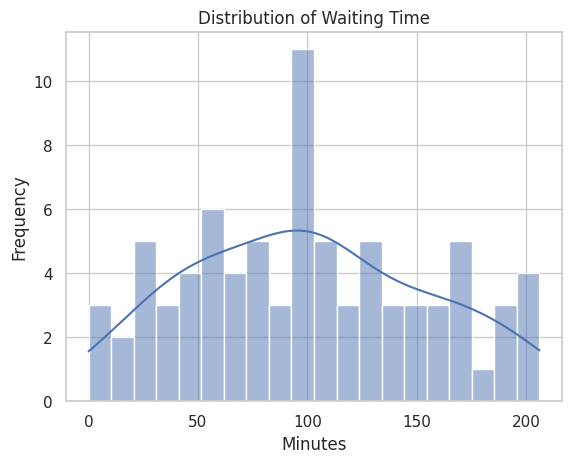

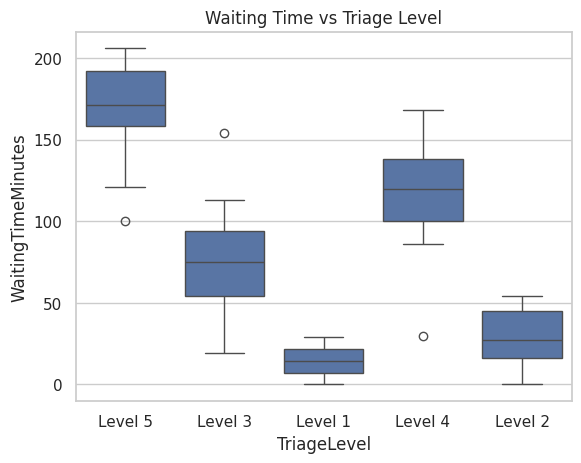

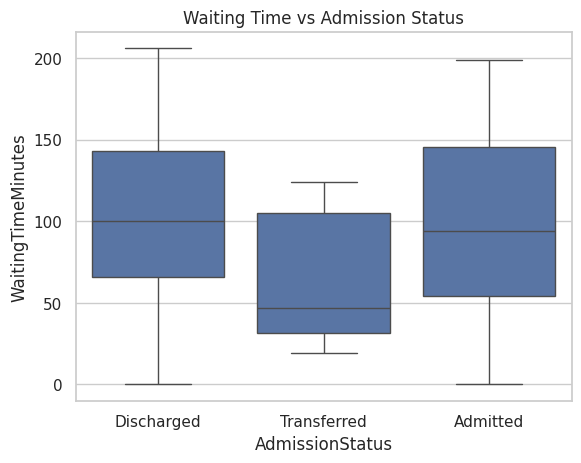


Final Cleaned Data:
  PatientID  Age  Gender       ArrivalTime TriageLevel  WaitingTimeMinutes  \
0     P1001   52  Female   21/02/2026 3:00     Level 5               204.0   
1     P1002   15  Female   24/02/2026 8:15     Level 3                58.0   
2     P1003   72  Female   08/02/2026 4:55     Level 5               100.0   
3     P1004   61  Female  04/02/2026 21:55     Level 3                66.0   
4     P1005   21   Other   18/02/2026 2:45     Level 1                29.0   

  DoctorAssigned AdmissionStatus  
0       Dr. Khan      Discharged  
1       Dr. Sara     Transferred  
2       Dr. Noor      Discharged  
3       Dr. Noor      Discharged  
4        Dr. Ali        Admitted  


In [1]:
# Hospital Emergency Room Waiting Time Analysis
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 2. UPLOAD DATASET
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
print("First 5 rows:")
print(df.head())

# 3. DATASET STRUCTURE
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe(include='all'))
print("\nUnique Values:")
for col in df.columns:
    print(col, ":", df[col].nunique())

# DATA QUALITY CHECKS
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Invalid Ages
if 'Age' in df.columns:
    invalid_age = df[(df['Age'] < 0) | (df['Age'] > 120)]
    print("\nInvalid Age Rows:")
    print(invalid_age)

# Category inconsistencies
for col in ['Gender', 'TriageLevel', 'AdmissionStatus']:
    if col in df.columns:
        print(f"\nUnique values in {col}:")
        print(df[col].unique())

# Handle missing values
if 'Age' in df.columns:
    df['Age'].fillna(df['Age'].median(), inplace=True)
if 'WaitingTimeMinutes' in df.columns:
    df['WaitingTimeMinutes'].fillna(df['WaitingTimeMinutes'].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fix invalid ages
if 'Age' in df.columns:
    df = df[(df['Age'] >= 0) & (df['Age'] <= 120)]
for col in ['Gender', 'AdmissionStatus', 'TriageLevel']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.capitalize()

# OUTLIER REMOVAL (IQR)
if 'WaitingTimeMinutes' in df.columns:
    Q1 = df['WaitingTimeMinutes'].quantile(0.25)
    Q3 = df['WaitingTimeMinutes'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df['WaitingTimeMinutes'] >= lower) &
            (df['WaitingTimeMinutes'] <= upper)]
print("\nData cleaned successfully!")

# UNIVARIATE ANALYSIS
plt.figure()
sns.histplot(df['WaitingTimeMinutes'], bins=20, kde=True)
plt.title("Distribution of Waiting Time")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

# BIVARIATE ANALYSIS
if 'TriageLevel' in df.columns:
    plt.figure()
    sns.boxplot(x='TriageLevel', y='WaitingTimeMinutes', data=df)
    plt.title("Waiting Time vs Triage Level")
    plt.show()

if 'AdmissionStatus' in df.columns:
    plt.figure()
    sns.boxplot(x='AdmissionStatus', y='WaitingTimeMinutes', data=df)
    plt.title("Waiting Time vs Admission Status")
    plt.show()

# FINAL CLEAN DATA PREVIEW
print("\nFinal Cleaned Data:")
print(df.head())

